# Linear Regression
Linear regression is a supervised machine learning algorithm. It builds a linear model that can predict the value of a real/continuous target variable based on independent variables (features).

Historical data. In machine learning, we call this a labeled dataset because for every past scenario, you have both the input and the actual outcome.The Feature ($X$): This is your independent variable. It is the information you are going to use to base your guess on.The Target ($Y$): This is your dependent variable. It is the actual result or answer that corresponds to the feature.

## The Equation

$$h_{\theta}(x) = \theta_{0}x_{0} + \theta_{1}x_{1} + \theta_{2}x_{2} + ... + \theta_{n}x_{n}$$

- $h_{\theta}(x)$ (The Hypothesis): This is your final prediction, this is that final number.
- $x$ (The Features): These are your inputs—the independent variables from your dataset. If you were predicting house prices, $x_{1}$ might be square footage, $x_{2}$ might be the number of bedrooms, $x_{3}$ might be the age of the house, and so on. (Note: $x_{0}$ is always just set to 1 so that $\theta_{0}$ can be a standalone number).
- $\theta$ (The Parameters / Weights): These are the "rules" the machine learning model actually learns during training.
    - $\theta_{0}$ is the Y-intercept (your baseline prediction when all features are 0).
    - $\theta_{1}, \theta_{2}, ... \theta_{n}$ are the Coefficients (slopes). They act as multipliers that decide how much "weight" or importance each specific feature has on the final prediction.

## Steps of Applying Linear Regression to a Dataset:
1. Analyze the dataset
2. Perform data preprocessing
3. Split the data into train and test sets
4. Fit the linear regression model to the training data
5. Evaluate the fitted model on the test data
6. Generate predictions for new data

Note: Some data preprocessing techniques should be performed after the splitting of data. So, we can swap the orders of steps 2 and 3, or perform step 3 at a certain point within step 2.

# Gradient Descent

**Gradient Descent** is an optimization algorithm used to find the parameters (theta) that minimize the cost/error function of a model.

The intuition:
Imagine you're on a hilly terrain blindfolded and want to reach the lowest point. You feel the slope under your feet and take a step in the downhill direction. You keep doing this until you reach the bottom. That's gradient descent.

## How it works:

1. Start with random theta values
2. Calculate the error (cost function)
3. Calculate the gradient (slope) of the error with respect to each theta
4. Update each theta by stepping in the opposite direction of the gradient:

$$\theta_j = \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}$$ (partial derivative of cost function)

5. Repeat until convergence


## Key terms:

- α (alpha) → learning rate, controls how big each step is
- Too large α → overshoot, never converge
- Too small α → converge very slowly
- Gradient → tells you the direction of steepest ascent, so you go the opposite way

# Example:

Suppose you are the CEO of a big company franchise and the company is considering different cities for opening a new store. The chain already has stores in various cities and you have the profits and population data of these cities. You would like to use this data to help you select which new city to expand to next. How can you do that?

You can fit a linear regression model to this data to predict the profit based on the population and then select the city which is expected to produce the highest profit.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

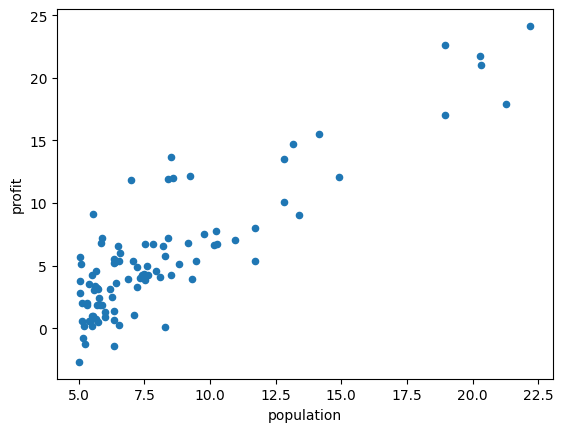

In [3]:
data = pd.read_csv('data.csv')

#step 1 (simple analysis through visualization)
data.plot(kind='scatter', x='population', y='profit')
plot.show()

In [4]:
#step 2
data = shuffle(data) #is simply randomizes the order of the rows in your dataset.

#Why do it? If your dataset happens to be sorted (for example, ordered from smallest population to largest),
#the algorithm might accidentally learn the order of the data rather than the actual relationship between population and profit.
#Shuffling ensures the model learns the true underlying pattern.
#This is especially critical right before you split the data into training and testing sets.

x = data['population'].to_numpy().reshape((-1,1))
y = data['profit'].to_numpy().reshape((-1,1))

#data['population']: This isolates the specific column you want from your Pandas DataFrame.
#to_numpy(): This converts that Pandas column into a standard NumPy array.
#Most machine learning libraries (like Scikit-Learn) are built on top of NumPy and perform matrix math under the hood.
#They prefer pure arrays over Pandas DataFrames.
#reshape((-1,1)): This is the most important part, and a classic "gotcha" in machine learning. When you extract a single column,
#Pandas gives you a 1-Dimensional array that looks like this: [5.0, 7.5, 10.0, ...]. Its shape is just (n,).
#However, Machine Learning libraries expect your features ($X$) to be a 2-Dimensional matrix (rows and columns),
#even if you only have one single feature.By using .
#reshape((-1, 1)), you are telling Python:The 1 means: "Force this data to have exactly 1 column.
#"The -1 means: "Calculate the number of rows automatically based on how much data there is."
#It transforms your flat array into a vertical column vector:Plaintext[[ 5.0],
#[ 7.5],
#[10.0],
#... ]

#step 3
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8)

#Why We Do This (Preventing "Overfitting")
#Imagine a professor gives you a practice exam to study, and then gives you the exact same exam for your final. If you score 100%,
#it doesn't mean you are smart; it just means you memorized the answers.
#Machine learning models do the exact same thing.
#If you train the model on all 100% of your data, and then test it on that same data, it will look like a perfect model.
#But the moment you give it new, unseen data, it will fail.
#By hiding 20% of the data during training, you force the model to learn the actual underlying pattern between population and profit,
#rather than just memorizing the spreadsheet.

In [5]:
#step 4
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#step 5
y_pred = model.predict(x_test)
print('Coefficients: \n', model.coef_, " ", model.intercept_)
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred))

Coefficients: 
 [[1.2308213]]   [-4.33206468]
Mean squared error: 7.76


In [7]:
#step 6
newData = pd.read_csv('new_data.csv', names=['city','population'])
test = newData['population'].to_numpy().reshape((-1, 1))
predictions = model.predict(test)

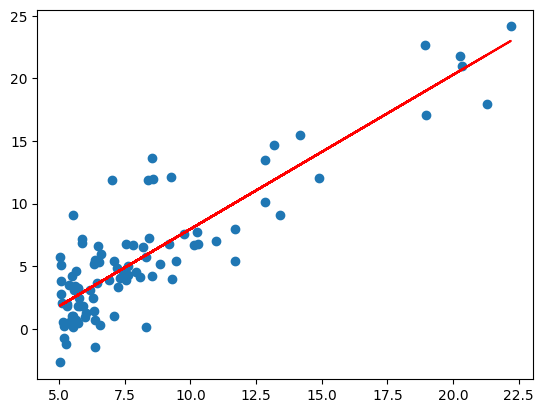

In [9]:
plot.scatter(x, y)
plot.plot(x, model.predict(x), color='red')

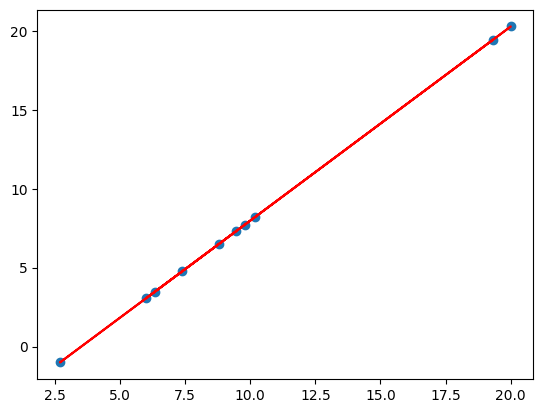

In [10]:
plot.scatter(newData['population'], predictions)
plot.plot(newData['population'], predictions, color='red')